<div style="
  font-size: 30px;
  background-color: #003366;
  padding: 15px;
  border-radius: 12px;
  color: white;
  text-align: center;
  font-weight: bold;
  animation: fadeIn 1.5s ease-in-out, glow 3s infinite alternate;
  box-shadow: 0 0 10px rgba(0,0,0,0.3);
  letter-spacing: 1px;
">
  SmartCare Hospital Analytics System
</div>

<style>
@keyframes fadeIn {
  0% { opacity: 0; transform: translateY(-10px); }
  100% { opacity: 1; transform: translateY(0); }
}

@keyframes glow {
  0% { box-shadow: 0 0 10px #0055cc, 0 0 20px #0055cc; }
  100% { box-shadow: 0 0 20px #0099ff, 0 0 40px #0099ff; }
}
</style>


#           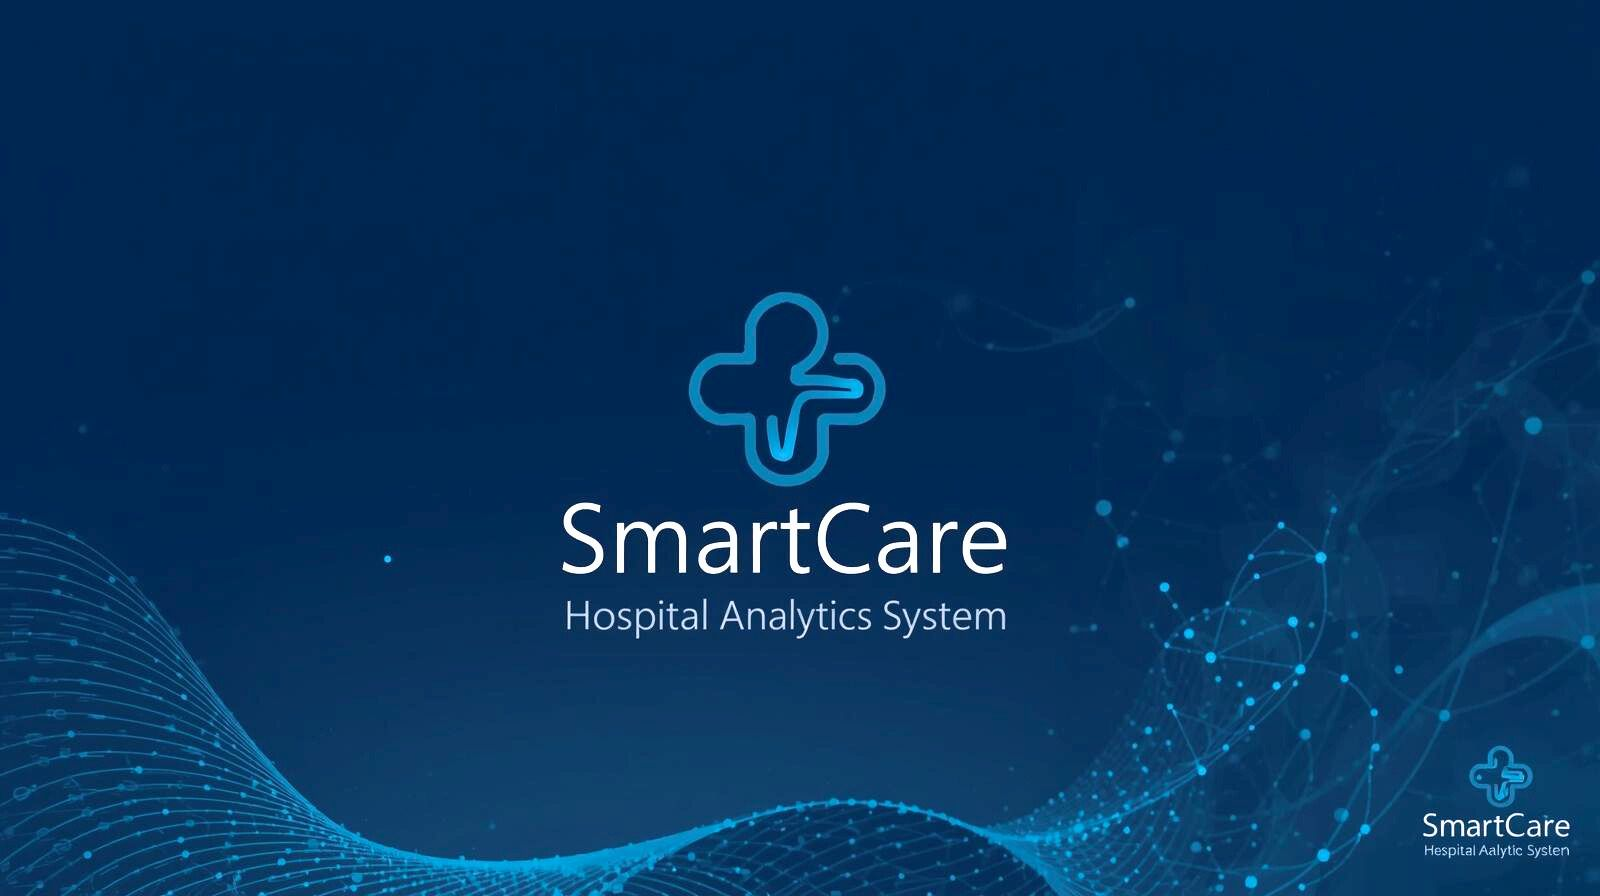

<div style="font-size: 24px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">1.Get Started</div>

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">
1.1 Importing Needed libraries And Files</div>


In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">
1.2 Reading Files</div>

In [132]:
encounters = pd.read_csv("D:\SmartCare Hospital\encounters.csv")
encounters.info()
encounters.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   encounter_id      70000 non-null  object 
 1   patient_id        70000 non-null  object 
 2   provider_id       70000 non-null  object 
 3   visit_date        70000 non-null  object 
 4   visit_type        70000 non-null  object 
 5   department        70000 non-null  object 
 6   reason_for_visit  70000 non-null  object 
 7   diagnosis_code    70000 non-null  object 
 8   admission_type    21594 non-null  object 
 9   discharge_date    24345 non-null  object 
 10  length_of_stay    24345 non-null  float64
 11  status            70000 non-null  object 
 12  readmitted_flag   70000 non-null  object 
dtypes: float64(1), object(12)
memory usage: 6.9+ MB


,length_of_stay
count,24345.000000
mean,2.499569
std,0.500010
min,2.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


In [133]:
patients = pd.read_csv("D:\SmartCare Hospital\patients.csv")
patients.info()
patients.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         60000 non-null  object 
 1   first_name         60000 non-null  object 
 2   last_name          60000 non-null  object 
 3   dob                60000 non-null  object 
 4   age                60000 non-null  int64  
 5   gender             60000 non-null  object 
 6   ethnicity          60000 non-null  object 
 7   insurance_type     60000 non-null  object 
 8   marital_status     60000 non-null  object 
 9   address            54063 non-null  object 
 10  city               54063 non-null  object 
 11  state              54063 non-null  object 
 12  zip                54063 non-null  float64
 13  phone              53996 non-null  object 
 14  email              47962 non-null  object 
 15  registration_date  60000 non-null  object 
dtypes: float64(1), int64(1

,age,zip
count,60000.000000,54063.000000
mean,46.987800,92196.901689
std,25.138112,4431.118184
min,4.000000,75001.000000
25%,25.000000,90802.000000
50%,47.000000,93301.000000
75%,69.000000,94203.000000
max,90.000000,98101.000000


In [134]:
providers = pd.read_csv("D:\SmartCare Hospital\providers.csv")
providers.info()
providers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   provider_id       1491 non-null   object
 1   name              1491 non-null   object
 2   department        1491 non-null   object
 3   specialty         1491 non-null   object
 4   npi               1491 non-null   int64 
 5   inhouse           1491 non-null   object
 6   location          1491 non-null   object
 7   years_experience  1491 non-null   int64 
 8   contact_info      1339 non-null   object
 9   email             1176 non-null   object
dtypes: int64(2), object(8)
memory usage: 116.6+ KB


,npi,years_experience
count,1.491000e+03,1491.000000
mean,5.540058e+09,12.539235
std,2.574575e+09,8.569356
min,1.007674e+09,1.000000
25%,3.325648e+09,6.000000
50%,5.533697e+09,12.000000
75%,7.689122e+09,17.000000
max,9.992324e+09,40.000000


In [135]:
billing = pd.read_csv("D:\SmartCare Hospital\claims_and_billing.csv")
billing.info()
billing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   billing_id          70000 non-null  object 
 1   patient_id          70000 non-null  object 
 2   encounter_id        70000 non-null  object 
 3   insurance_provider  70000 non-null  object 
 4   payment_method      70000 non-null  object 
 5   claim_id            59638 non-null  object 
 6   claim_billing_date  59638 non-null  object 
 7   billed_amount       70000 non-null  float64
 8   paid_amount         70000 non-null  float64
 9   claim_status        70000 non-null  object 
 10  denial_reason       5998 non-null   object 
dtypes: float64(2), object(9)
memory usage: 5.9+ MB


,billed_amount,paid_amount
count,70000.000000,70000.000000
mean,1612.866283,1040.652151
std,2047.355083,1478.713641
min,100.070000,0.000000
25%,697.047500,366.572500
50%,1214.110000,755.785000
75%,2090.125000,1357.895000
max,38191.350000,38191.350000


In [136]:
denials = pd.read_csv("D:\SmartCare Hospital\denials.csv")
denials.info()
denials.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   claim_id                   5998 non-null   object 
 1   denial_id                  5998 non-null   object 
 2   denial_reason_code         5998 non-null   object 
 3   denial_reason_description  5998 non-null   object 
 4   denied_amount              5998 non-null   float64
 5   denial_date                5998 non-null   object 
 6   appeal_filed               5998 non-null   object 
 7   appeal_status              5396 non-null   object 
 8   appeal_resolution_date     5396 non-null   object 
 9   final_outcome              5396 non-null   object 
dtypes: float64(1), object(9)
memory usage: 468.7+ KB


,denied_amount
count,5998.00000
mean,1608.16611
std,1933.33737
min,101.58000
25%,697.38500
50%,1221.51000
75%,2102.14750
max,35956.07000


In [137]:
diagnosis = pd.read_csv('D:\SmartCare Hospital\diagnoses.csv')
diagnosis.info()
diagnosis.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   diagnosis_id           70000 non-null  object
 1   encounter_id           70000 non-null  object
 2   diagnosis_code         70000 non-null  object
 3   diagnosis_description  70000 non-null  object
 4   primary_flag           70000 non-null  bool  
 5   chronic_flag           70000 non-null  bool  
dtypes: bool(2), object(4)
memory usage: 2.3+ MB


,diagnosis_id,encounter_id,diagnosis_code,diagnosis_description,primary_flag,chronic_flag
count,70000,70000,70000,70000,70000,70000
unique,63,70000,63,63,1,2
top,DIA0050,ENC069984,S09.90XA,"Unspecified injury of head, initial encounter",True,False
freq,5483,1,5483,5483,70000,37246


In [138]:
medications = pd.read_csv("D:\SmartCare Hospital\medications.csv")
medications.info()
medications.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94498 entries, 0 to 94497
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   medication_id    94498 non-null  object 
 1   encounter_id     94498 non-null  object 
 2   drug_name        94498 non-null  object 
 3   dosage           94498 non-null  object 
 4   route            94498 non-null  object 
 5   frequency        94498 non-null  object 
 6   duration         94498 non-null  object 
 7   prescribed_date  94498 non-null  object 
 8   prescriber_id    94498 non-null  object 
 9   cost             94498 non-null  float64
dtypes: float64(1), object(9)
memory usage: 7.2+ MB


,cost
count,94498.000000
mean,127.388622
std,1245.582249
min,2.000000
25%,5.000000
50%,7.500000
75%,15.000000
max,18000.000000


In [139]:
lab_test = pd.read_csv("D:\SmartCare Hospital\lab_tests.csv")
lab_test.info()
lab_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54537 entries, 0 to 54536
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lab_id         54537 non-null  object
 1   encounter_id   54537 non-null  object
 2   test_name      54537 non-null  object
 3   test_code      54537 non-null  object
 4   specimen_type  54537 non-null  object
 5   test_result    54537 non-null  object
 6   units          14972 non-null  object
 7   normal_range   2792 non-null   object
 8   test_date      54537 non-null  object
 9   status         54537 non-null  object
dtypes: object(10)
memory usage: 4.2+ MB


,lab_id,encounter_id,test_name,test_code,specimen_type,test_result,units,normal_range,test_date,status
count,54537,54537,54537,54537,54537,54537,14972,2792,54537,54537
unique,17,38182,59,59,5,3,3,3,90,3
top,LAB010,ENC064613,Collection of venous blood by venipuncture,TEST003,Imaging,Preliminary,mg/dL,4.5-11.0 x10^3/uL,13-02-2025,Preliminary
freq,13461,4,6573,6573,20107,18345,9299,1394,710,18307


In [140]:
procedures = pd.read_csv('D:\SmartCare Hospital\procedures.csv')
procedures.info()
procedures.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126021 entries, 0 to 126020
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   procedure_id           126021 non-null  object 
 1   encounter_id           126021 non-null  object 
 2   procedure_code         126021 non-null  object 
 3   procedure_description  126021 non-null  object 
 4   procedure_date         126021 non-null  object 
 5   provider_id            126021 non-null  object 
 6   procedure_cost         126021 non-null  float64
dtypes: float64(1), object(6)
memory usage: 6.7+ MB


,procedure_cost
count,126021.000000
mean,800.363986
std,404.172594
min,100.030000
25%,451.210000
50%,800.480000
75%,1149.190000
max,1499.990000


In [141]:
lab_tests= pd.read_csv("D:\SmartCare Hospital\lab_tests.csv")
lab_tests.info()
lab_tests.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54537 entries, 0 to 54536
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lab_id         54537 non-null  object
 1   encounter_id   54537 non-null  object
 2   test_name      54537 non-null  object
 3   test_code      54537 non-null  object
 4   specimen_type  54537 non-null  object
 5   test_result    54537 non-null  object
 6   units          14972 non-null  object
 7   normal_range   2792 non-null   object
 8   test_date      54537 non-null  object
 9   status         54537 non-null  object
dtypes: object(10)
memory usage: 4.2+ MB


,lab_id,encounter_id,test_name,test_code,specimen_type,test_result,units,normal_range,test_date,status
count,54537,54537,54537,54537,54537,54537,14972,2792,54537,54537
unique,17,38182,59,59,5,3,3,3,90,3
top,LAB010,ENC064613,Collection of venous blood by venipuncture,TEST003,Imaging,Preliminary,mg/dL,4.5-11.0 x10^3/uL,13-02-2025,Preliminary
freq,13461,4,6573,6573,20107,18345,9299,1394,710,18307


<div style="font-size: 24px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">
2. Data Cleaning And Preprocessing</div>

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.1 Remove Unnecessary Tables</div>

In [142]:
del lab_tests,diagnosis

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">
2.2 Create BackUp For Row Data Set</div>

In [143]:
for df in [encounters,patients,providers,billing,denials,medications,procedures]:
  df_backup = df.copy(deep=True)

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.3 Inspect Data Consistancy</div>

In [144]:
for df in [encounters, patients, providers, billing, denials, medications, procedures]:
  print(df.isnull().sum())

encounter_id            0
patient_id              0
provider_id             0
visit_date              0
visit_type              0
department              0
reason_for_visit        0
diagnosis_code          0
admission_type      48406
discharge_date      45655
length_of_stay      45655
status                  0
readmitted_flag         0
dtype: int64
patient_id               0
first_name               0
last_name                0
dob                      0
age                      0
gender                   0
ethnicity                0
insurance_type           0
marital_status           0
address               5937
city                  5937
state                 5937
zip                   5937
phone                 6004
email                12038
registration_date        0
dtype: int64
provider_id           0
name                  0
department            0
specialty             0
npi                   0
inhouse               0
location              0
years_experience      0
contact_info

<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.4 Remove Unnecessary Columns</div>

In [145]:
encounters.drop([ "admission_type", "discharge_date", "length_of_stay"],
                axis=1, inplace=True, errors = 'ignore')
encounters

,encounter_id,patient_id,provider_id,visit_date,visit_type,department,reason_for_visit,diagnosis_code,status,readmitted_flag
0,ENC017535,PAT000001,PRO00865,03-01-2025,Outpatient,Obstetrics & Gynecology,Irregular Menstruation,N92.6,Completed,Yes
1,ENC030367,PAT000001,PRO00579,30-03-2025,Telehealth,Gastroenterology,IBS,K58.9,Completed,Yes
2,ENC038533,PAT000002,PRO01227,26-02-2025,Inpatients,Dermatology,Acne,L70.9,Completed,No
3,ENC056041,PAT000003,PRO00055,27-01-2025,Emergency,Emergency Department,Accidental Injury,S09.90XA,Completed,No
4,ENC046849,PAT000004,PRO00043,26-01-2025,Emergency,Emergency Department,Accidental Injury,S09.90XA,Completed,No
...,...,...,...,...,...,...,...,...,...,...
69995,ENC050405,PAT059997,PRO00021,02-02-2025,Emergency,Emergency Department,Sudden Breathing Issue,R06.02,Completed,No
69996,ENC062201,PAT059997,PRO01338,20-03-2025,Outpatient,ENT (Otolaryngology),Sinus Infection,J01.90,Completed,No
69997,ENC046514,PAT059998,PRO00350,19-02-2025,Inpatients,Pulmonology,COPD Check,J44.9,Completed,No
69998,ENC062848,PAT059999,PRO00730,28-02-2025,Inpatients,Oncology,Cancer Follow-up,C50.919,Completed,No


In [146]:
patients.drop([ "zip", "address", "phone","email"],
                axis=1, inplace=True, errors = 'ignore')
patients.head(5)

,patient_id,first_name,last_name,dob,age,gender,ethnicity,insurance_type,marital_status,city,state,registration_date
0,PAT000001,Danielle,Johnson,14-05-1940,85,Female,Asian,UHC,Married,Bakersfield,CA,03-01-2025
1,PAT000002,Anna,Baldwin,04-03-2010,15,Female,White,Aetna,Married,Bakersfield,CA,26-02-2025
2,PAT000003,James,Jones,31-03-2021,4,Male,White,UHC,Married,Portland,OR,27-01-2025
3,PAT000004,Veronica,Bowman,26-08-1976,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,Seattle,WA,26-01-2025
4,PAT000005,Carl,Gentry,06-01-1942,83,Male,Hispanic,BCBS,Married,NaN,NaN,14-03-2025


In [147]:
providers.drop(["email","npi","contact_info"], axis=1, inplace=True, errors = 'ignore')
providers.head(5)

,provider_id,name,department,specialty,inhouse,location,years_experience
0,PRO00001,Michael Hernandez,Emergency Department,General Practitioner,Yes,CA,16
1,PRO00002,Dawn Owens,Emergency Department,General Practitioner,Yes,CA,5
2,PRO00003,Catherine Knight,Emergency Department,General Practitioner,Yes,CA,4
3,PRO00004,Roy Williams,Emergency Department,General Practitioner,Yes,CA,20
4,PRO00005,Cheryl Norris,Emergency Department,General Practitioner,Yes,CA,15


In [148]:
medications.drop(["route",'dosage','frequancy','duration'], axis=1, inplace=True, errors = 'ignore')
medications.head(5)

,medication_id,encounter_id,drug_name,frequency,prescribed_date,prescriber_id,cost
0,MED00001,ENC031127,Alprazolam,Twice daily,11-01-2025,PRO01436,8.0
1,MED00002,ENC051072,Folic Acid,Once daily,12-02-2025,PRO00919,3.0
2,MED00003,ENC019653,Folic Acid,Once daily,30-03-2025,PRO00893,3.0
3,MED00004,ENC047035,Dolutegravir,Once daily,02-02-2025,PRO01388,450.0
4,MED00004,ENC047035,Atazanavir,Once daily,02-02-2025,PRO01388,500.0


<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.5 Detect Duplictes</div>

In [149]:
for x in [encounters,patients,providers,billing,denials,medications,procedures]:
  print(x.duplicated().sum())

0
0
0
0
0
0
0


<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.6 Remove Data Inconsistant</div>

In [150]:
# en_p = encounters.merge(patients[['patient_id','age']], on='patient_id', how='inner')
# en_p = en_p[~((en_p['age'] < 16) & (en_p['reason_for_visit'] == 'Prenatal visit'))]

merged = patients.merge(encounters[['patient_id', 'reason_for_visit']], on='patient_id', how='left')

patients_to_remove = merged.loc[
    (merged['age'] < 16) & (merged['reason_for_visit'] ==  'Prenatal visit'),
    'patient_id'
]


patients = patients[~patients['patient_id'].isin(patients_to_remove)]



<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.7 Detect Missing Values</div>



In [151]:
for missing in [encounters,patients,providers,billing,denials,medications,procedures]:
  print(missing.isnull().sum())

encounter_id        0
patient_id          0
provider_id         0
visit_date          0
visit_type          0
department          0
reason_for_visit    0
diagnosis_code      0
status              0
readmitted_flag     0
dtype: int64
patient_id              0
first_name              0
last_name               0
dob                     0
age                     0
gender                  0
ethnicity               0
insurance_type          0
marital_status          0
city                 5937
state                5937
registration_date       0
dtype: int64
provider_id         0
name                0
department          0
specialty           0
inhouse             0
location            0
years_experience    0
dtype: int64
billing_id                0
patient_id                0
encounter_id              0
insurance_provider        0
payment_method            0
claim_id              10362
claim_billing_date    10362
billed_amount             0
paid_amount               0
claim_status           

In [152]:
city_mode = patients['city'].mode()[0]
state_mode = patients['state'].mode()[0]
print(" Most frequent city:", city_mode)
print(" Most frequent state:", state_mode)

 Most frequent city: Anaheim
 Most frequent state: CA


In [153]:
patients['city'].fillna(city_mode, inplace=True)
patients['state'].fillna(state_mode, inplace=True)

C:\Users\Radwa\AppData\Local\Temp\ipykernel_23356\1326229329.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Radwa\AppData\Local\Temp\ipykernel_23356\1326229329.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [154]:
# combine first name and last name
patients["full_name"] = patients["first_name"] + " " + patients["last_name"]
patients.head(5)

,patient_id,first_name,last_name,dob,age,gender,ethnicity,insurance_type,marital_status,city,state,registration_date,full_name
0,PAT000001,Danielle,Johnson,14-05-1940,85,Female,Asian,UHC,Married,Bakersfield,CA,03-01-2025,Danielle Johnson
1,PAT000002,Anna,Baldwin,04-03-2010,15,Female,White,Aetna,Married,Bakersfield,CA,26-02-2025,Anna Baldwin
2,PAT000003,James,Jones,31-03-2021,4,Male,White,UHC,Married,Portland,OR,27-01-2025,James Jones
3,PAT000004,Veronica,Bowman,26-08-1976,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,Seattle,WA,26-01-2025,Veronica Bowman
4,PAT000005,Carl,Gentry,06-01-1942,83,Male,Hispanic,BCBS,Married,Anaheim,CA,14-03-2025,Carl Gentry


In [155]:
# drop first name and last name
patients.drop(["first_name" , "last_name"], axis=1, inplace = True ,errors = 'ignore')
patients.head(5)

,patient_id,dob,age,gender,ethnicity,insurance_type,marital_status,city,state,registration_date,full_name
0,PAT000001,14-05-1940,85,Female,Asian,UHC,Married,Bakersfield,CA,03-01-2025,Danielle Johnson
1,PAT000002,04-03-2010,15,Female,White,Aetna,Married,Bakersfield,CA,26-02-2025,Anna Baldwin
2,PAT000003,31-03-2021,4,Male,White,UHC,Married,Portland,OR,27-01-2025,James Jones
3,PAT000004,26-08-1976,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,Seattle,WA,26-01-2025,Veronica Bowman
4,PAT000005,06-01-1942,83,Male,Hispanic,BCBS,Married,Anaheim,CA,14-03-2025,Carl Gentry


<div style="font-size: 20px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">2.8 Handle Date Format</div>

In [156]:
# in encounters table
encounters["visit_date"] = pd.to_datetime(encounters["visit_date"], errors="coerce")


# in patients table
patients["dob"] = pd.to_datetime(patients["dob"],errors = "coerce")
patients["registration_date"] = pd.to_datetime(patients["registration_date"],errors = "coerce")
# in billing table
billing["claim_billing_date"] = pd.to_datetime(billing["claim_billing_date"],errors = "coerce")

# in denials table
denials["denial_date"] = pd.to_datetime(denials["denial_date"],errors = "coerce")
denials["appeal_resolution_date"] = pd.to_datetime(denials["appeal_resolution_date"],errors = "coerce")

# in medication table
medications["prescribed_date"] = pd.to_datetime(medications["prescribed_date"],errors = "coerce")

# in procedures table
procedures["procedure_date"] = pd.to_datetime(procedures["procedure_date"],errors = "coerce")

In [157]:

patients.head(5)

,patient_id,dob,age,gender,ethnicity,insurance_type,marital_status,city,state,registration_date,full_name
0,PAT000001,1940-05-14,85,Female,Asian,UHC,Married,Bakersfield,CA,2025-01-03,Danielle Johnson
1,PAT000002,2010-03-04,15,Female,White,Aetna,Married,Bakersfield,CA,2025-02-26,Anna Baldwin
2,PAT000003,2021-03-31,4,Male,White,UHC,Married,Portland,OR,2025-01-27,James Jones
3,PAT000004,1976-08-26,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,Seattle,WA,2025-01-26,Veronica Bowman
4,PAT000005,1942-01-06,83,Male,Hispanic,BCBS,Married,Anaheim,CA,2025-03-14,Carl Gentry


In [158]:
# Calculate age of patients from dob(birth_date)
today = pd.Timestamp(date.today())
patients["age"] = (today - patients["dob"]).dt.days // 365
patients.head(5)

,patient_id,dob,age,gender,ethnicity,insurance_type,marital_status,city,state,registration_date,full_name
0,PAT000001,1940-05-14,85,Female,Asian,UHC,Married,Bakersfield,CA,2025-01-03,Danielle Johnson
1,PAT000002,2010-03-04,15,Female,White,Aetna,Married,Bakersfield,CA,2025-02-26,Anna Baldwin
2,PAT000003,2021-03-31,4,Male,White,UHC,Married,Portland,OR,2025-01-27,James Jones
3,PAT000004,1976-08-26,49,Female,Hispanic,BCBS,Widowed/Divorced/Separated,Seattle,WA,2025-01-26,Veronica Bowman
4,PAT000005,1942-01-06,83,Male,Hispanic,BCBS,Married,Anaheim,CA,2025-03-14,Carl Gentry


In [159]:
billing["claim_id"] = billing["claim_id"].fillna("no claim")
billing.head(5)

,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,2025-06-02,1971.52,0.00,Denied,Claim Billed to Wrong Payer
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,2025-01-05,1243.80,736.05,Paid,NaN
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,NaT,4854.11,2676.12,Paid,NaN
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,NaT,2638.21,1861.39,Paid,NaN
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,no claim,NaT,1046.99,1046.99,Paid,NaN


In [160]:
 # fill missing values
denials["appeal_status"] = denials["appeal_status"].fillna("no appeal filled")
denials["final_outcome"] = denials["final_outcome"].fillna("no appeal filled")
denials["appeal_resolution_date"] = denials["appeal_resolution_date"].fillna("no appeal filled")

denials["appeal_resolution_date"] = pd.to_datetime(denials["appeal_resolution_date"], errors="coerce")
denials.head(5)

,claim_id,denial_id,denial_reason_code,denial_reason_description,denied_amount,denial_date,appeal_filed,appeal_status,appeal_resolution_date,final_outcome
0,CLM000001,DEN00001,CO119,Claim billed to wrong payer.,1971.52,2025-03-01,Yes,Approved,2025-03-10,Paid
1,CLM000009,DEN00010,PR109,Claim not covered by this payer/contractor.,912.98,2025-04-02,No,no appeal filled,NaT,no appeal filled
2,CLM000021,DEN00024,CO18,Duplicate claim/service.,2078.53,2025-03-30,Yes,Approved,2025-04-04,Paid
3,CLM000032,DEN00035,CO50,These services are not medically necessary.,2242.83,2025-04-29,No,no appeal filled,NaT,no appeal filled
4,CLM000044,DEN00052,PR109,Claim not covered by this payer/contractor.,1157.46,2025-05-16,Yes,Approved,2025-05-23,Paid


In [161]:
# Change Prescriber_id to provider_id
medications= medications.rename(columns={"prescriber_id" : "provider_id"})
medications.head(5)

,medication_id,encounter_id,drug_name,frequency,prescribed_date,provider_id,cost
0,MED00001,ENC031127,Alprazolam,Twice daily,2025-01-11,PRO01436,8.0
1,MED00002,ENC051072,Folic Acid,Once daily,2025-02-12,PRO00919,3.0
2,MED00003,ENC019653,Folic Acid,Once daily,2025-03-30,PRO00893,3.0
3,MED00004,ENC047035,Dolutegravir,Once daily,2025-02-02,PRO01388,450.0
4,MED00004,ENC047035,Atazanavir,Once daily,2025-02-02,PRO01388,500.0


<div style="font-size: 24px; background-color: #003366; padding: 15px; border-radius: 12px;color: white">3. Data Modeling</div>


In [162]:
merged_encounters = pd.merge(encounters[["patient_id","encounter_id"]],patients[["patient_id","full_name"]], on="patient_id",how="inner")

<div style="font-size: 20px; background-color: #003366; padding: 15px;border-radius: 12px; 
            color: white; ;">4. EDA</div>


<div style="font-size: 20px; background-color: #003366; padding: 15px;border-radius: 12px; 
            color: white; ;">4.1 Overview</div>
            

In [163]:
# 1. How many encounters per patient?
encounters_per_patient = encounters['patient_id'].value_counts()
print(encounters_per_patient.head())

patient_id
PAT038089    5
PAT048145    5
PAT052502    5
PAT054767    4
PAT004374    4
Name: count, dtype: int64


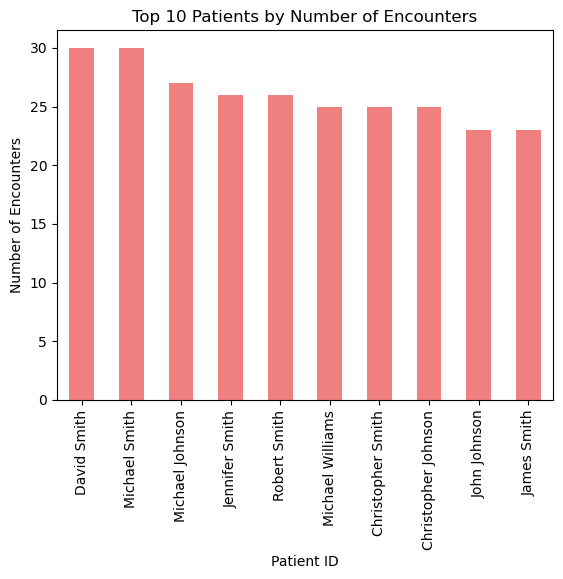

In [164]:
encounters_per_patient = merged_encounters['full_name'].value_counts()

encounters_per_patient.head(10).plot(kind='bar', color="lightcoral")
plt.title("Top 10 Patients by Number of Encounters")
plt.xlabel("Patient ID")
plt.ylabel("Number of Encounters")
plt.show()

In [165]:
del merged_encounters
import gc
gc.collect()


4962

In [166]:
# 2️. How many encounters per department?
dept_counts = encounters['department'].value_counts()
print(dept_counts)

department
Emergency Department              16365
Obstetrics & Gynecology            9242
General Surgery                    2545
Radiology / Imaging                2428
Cardiology                         2426
Urology                            2405
Pulmonology                        2404
Gastroenterology                   2392
Internal Medicine                  2372
ENT (Otolaryngology)               2368
Neurology                          2364
Infectious Disease                 2349
Family Medicine                    2348
Pathology / Lab Services           2335
Orthopedics                        2296
Psychiatry / Behavioral Health     2286
Nephrology                         2263
Oncology                           2253
Anesthesiology                     2252
Dermatology                        2237
Pediatrics                         2070
Name: count, dtype: int64


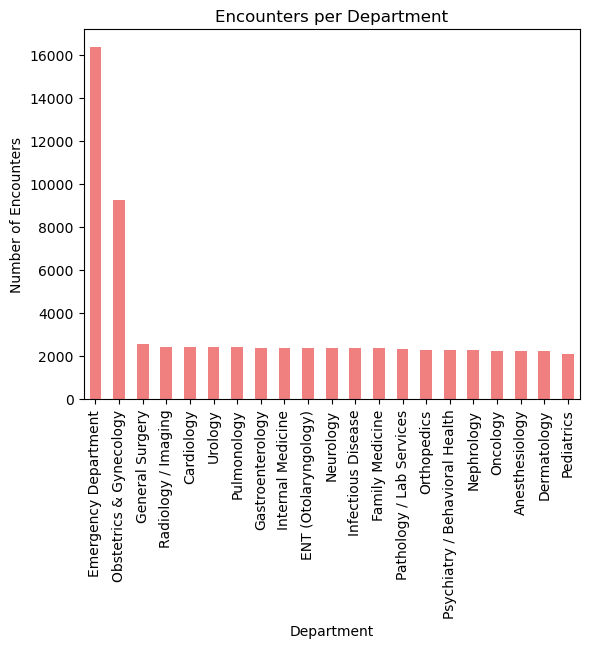

In [167]:
dept_counts.plot(kind='bar', color ="lightcoral")
plt.title("Encounters per Department")
plt.xlabel("Department")
plt.ylabel("Number of Encounters")
plt.show()

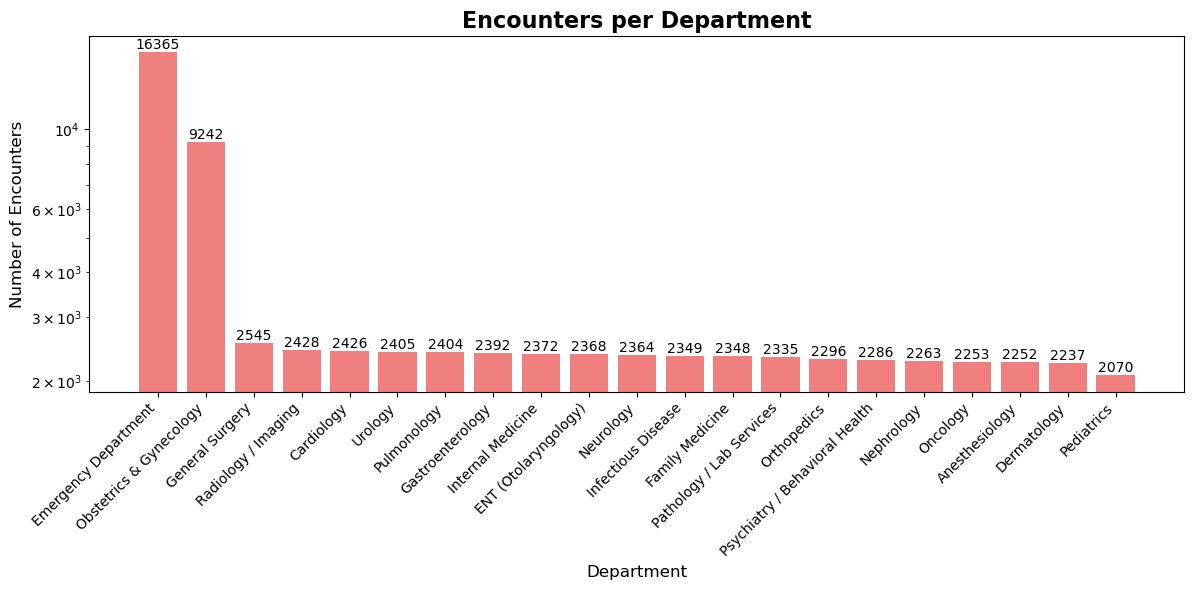

In [168]:
#Using LogTrick
dept_counts = dept_counts.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(dept_counts.index, dept_counts.values, color='lightcoral')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
            ha='center', va='bottom', fontsize=10)
ax.set_title("Encounters per Department", fontsize=16, fontweight='bold')
ax.set_xlabel("Department", fontsize=12)
ax.set_ylabel("Number of Encounters", fontsize=12)
plt.tight_layout() 
ax.set_yscale('log')
plt.show()

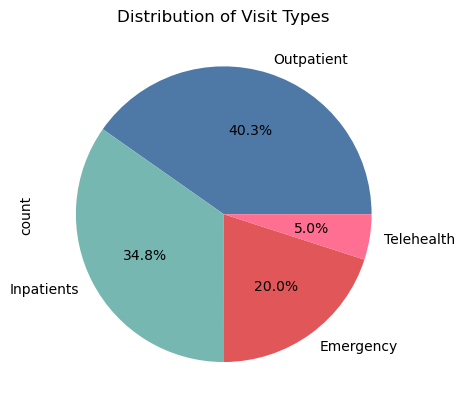

In [169]:
# 3️. How many encounters by visit type?
encounters['visit_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors = [  "#4E79A7","#76B7B2",  "#E15759", "#FF6F91"])
plt.title("Distribution of Visit Types")
plt.show()

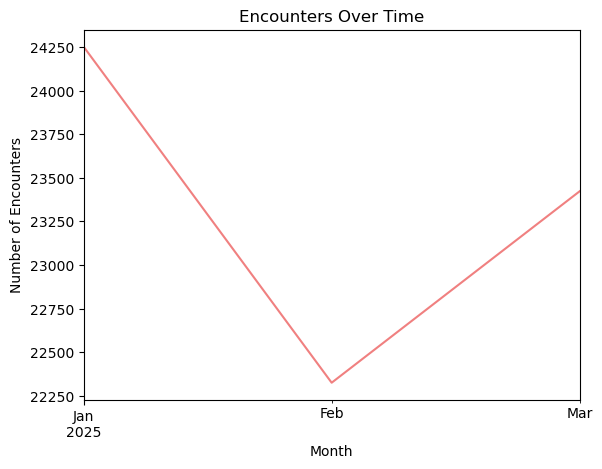

In [170]:
# 4. Trend of encounters over time
encounters.groupby(encounters['visit_date'].dt.to_period('M')).size().plot(kind='line' , color = "lightcoral")

plt.title("Encounters Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Encounters")
plt.show()

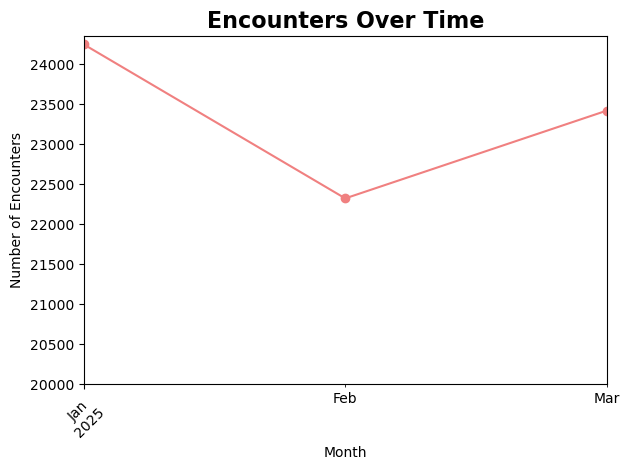

In [171]:

monthly_counts = encounters.groupby(encounters['visit_date'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.to_timestamp()


monthly_counts.plot(kind='line', color='lightcoral', marker='o')

plt.title("Encounters Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45)

plt.ylim(20000, monthly_counts.max() + 100) 
plt.tight_layout()
plt.show()


readmitted_flag
No     59003
Yes    10997
Name: count, dtype: int64


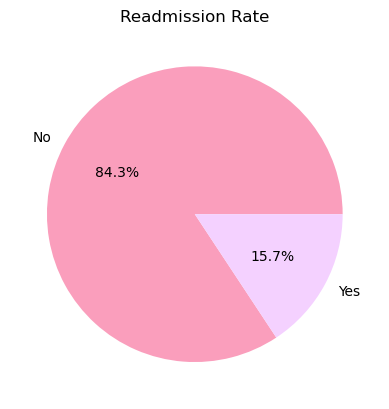

In [172]:
# 5️. Readmission Analysis
readmit_counts = encounters['readmitted_flag'].value_counts()
print(readmit_counts)

readmit_counts.plot(kind='pie', autopct='%1.1f%%', colors=["#fa9ebc","#f4d1ff"])
plt.title("Readmission Rate")
plt.ylabel("")
plt.show()

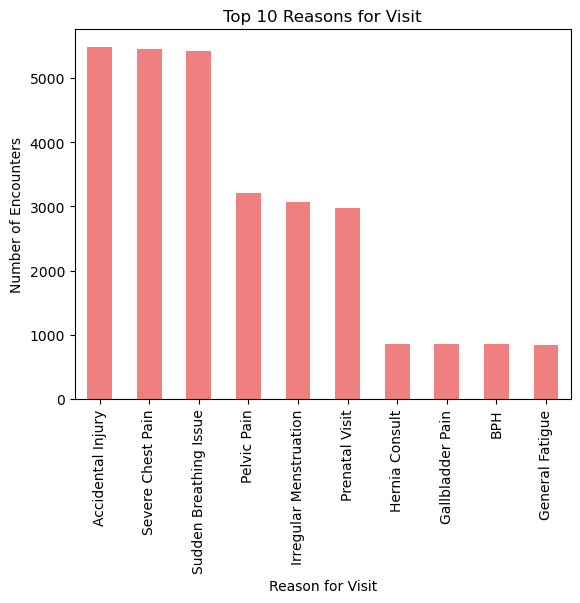

In [173]:
# 6️ Top Reasons for Visit
encounters['reason_for_visit'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title("Top 10 Reasons for Visit")
plt.xlabel("Reason for Visit")
plt.ylabel("Number of Encounters")
plt.show()

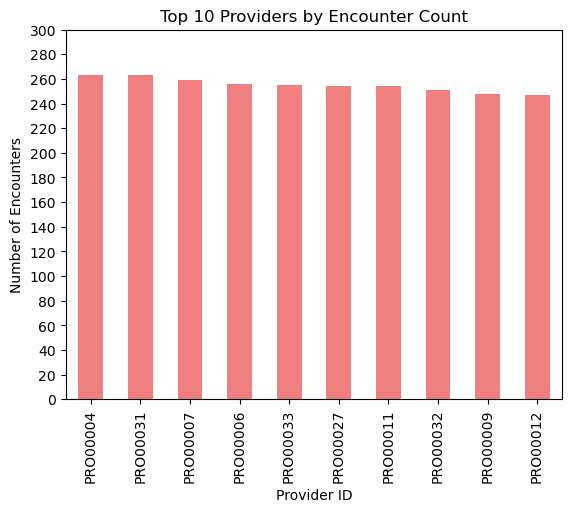

In [174]:
# 6. Provider Workload
encounters['provider_id'].value_counts().head(10).plot(kind='bar', color='lightcoral')

plt.title("Top 10 Providers by Encounter Count")
plt.xlabel("Provider ID")
plt.ylabel("Number of Encounters")
plt.ylim(0,300)
plt.yticks(np.arange(0, 301, 20))
plt.show()

In [175]:
merge_encounters2 = pd.merge(encounters,providers,on='provider_id',how="inner")

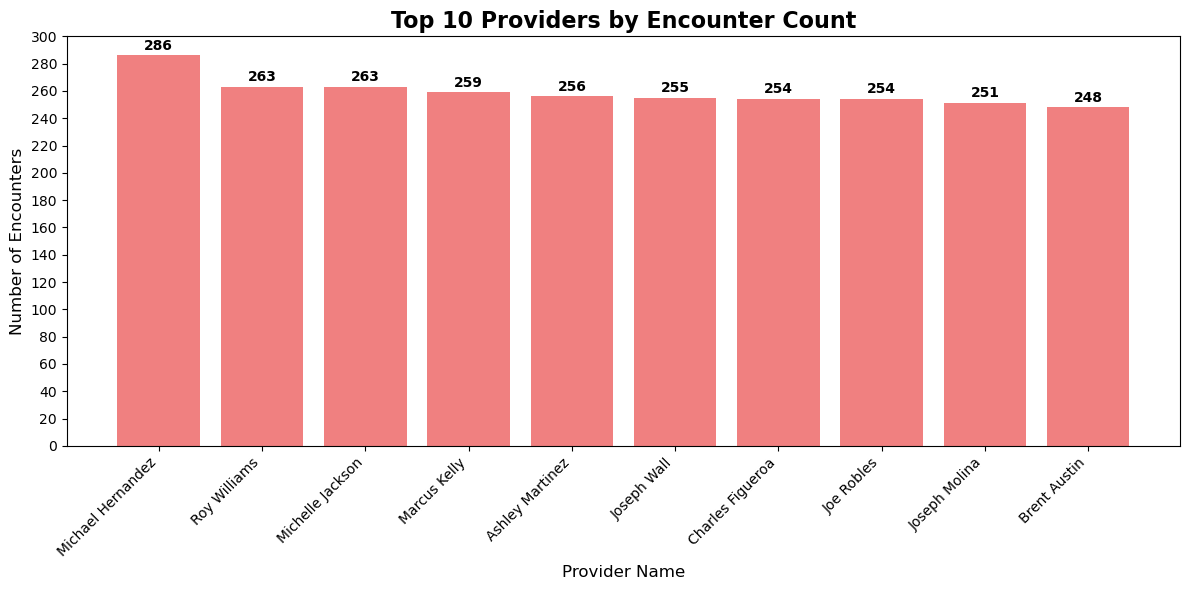

In [176]:
# Providers WorkLoad
top_providers = merge_encounters2["name"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(top_providers.index.astype(str), top_providers.values, color='lightcoral')

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,   
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title("Top 10 Providers by Encounter Count", fontsize=16, fontweight='bold')
ax.set_xlabel("Provider Name", fontsize=12)
ax.set_ylabel("Number of Encounters", fontsize=12)
ax.set_ylim(0, 300)
plt.xticks(rotation=45, ha='right')
ax.set_yticks(np.arange(0, 301, 20))
plt.tight_layout()
plt.show()


In [177]:
del merge_encounters2
import gc
gc.collect()

32860

In [178]:
##patient analysis



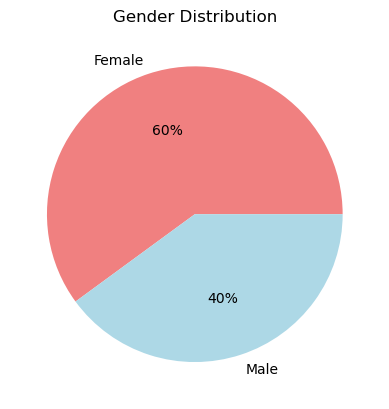

In [179]:
# 1️. Gender Distribution
patients['gender'].value_counts().plot(kind='pie', autopct='%1.f%%', colors=['lightcoral', 'lightblue'])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

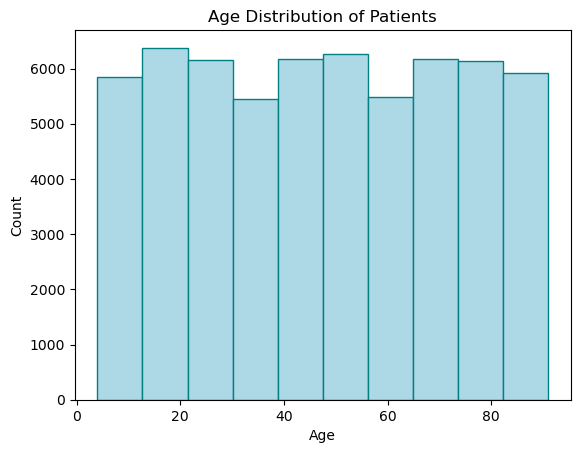

In [180]:
# 2️. Age Distribution
patients['age'].plot(kind='hist', bins=10, color='lightblue', edgecolor='teal')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

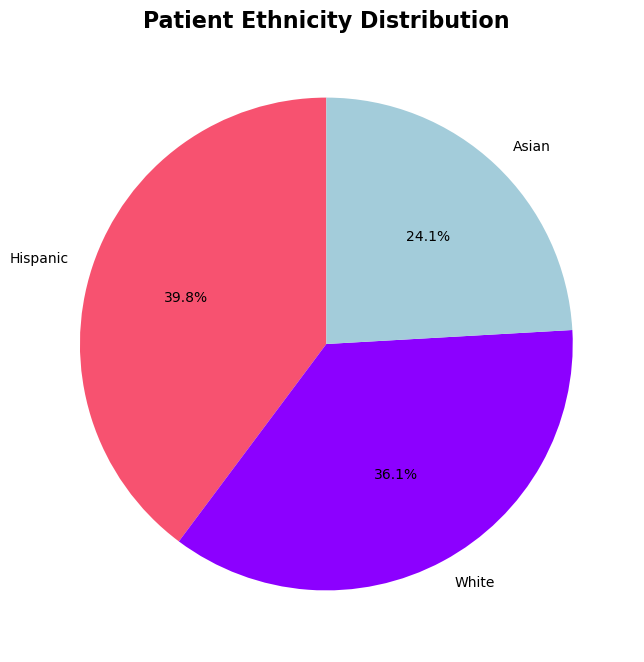

In [181]:
# 3. ethnicity type
ethnicity_counts = patients['ethnicity'].value_counts()

colors = ["#F75270", "#8C00FF", "#A3CCDA"][:len(ethnicity_counts)]
plt.figure(figsize=(8,8))
plt.pie(ethnicity_counts, labels=ethnicity_counts.index, 
        colors=colors, autopct='%1.1f%%', startangle=90)

plt.title("Patient Ethnicity Distribution", fontsize=16, fontweight='bold')
plt.show()


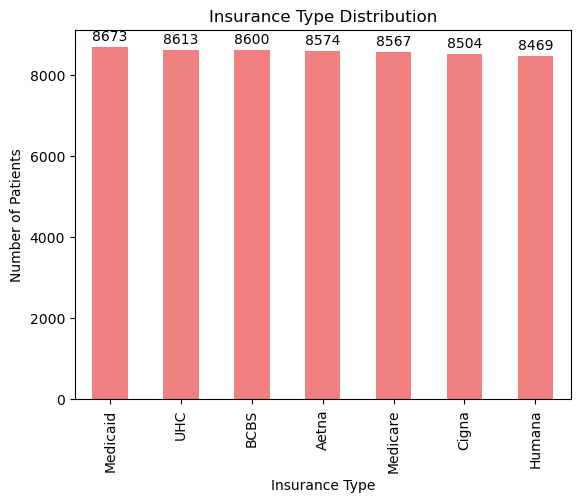

In [182]:
# 4️. Insurance Type Usage

ax = patients['insurance_type'].value_counts().plot(kind='bar', color='lightcoral')
plt.title("Insurance Type Distribution")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Patients")

# Add values above each bar
for i, v in enumerate(patients['insurance_type'].value_counts()):
    ax.text(i, v + 0.01 * max(patients['insurance_type'].value_counts()), 
            str(v), 
            ha='center', 
            va='bottom')

plt.show()

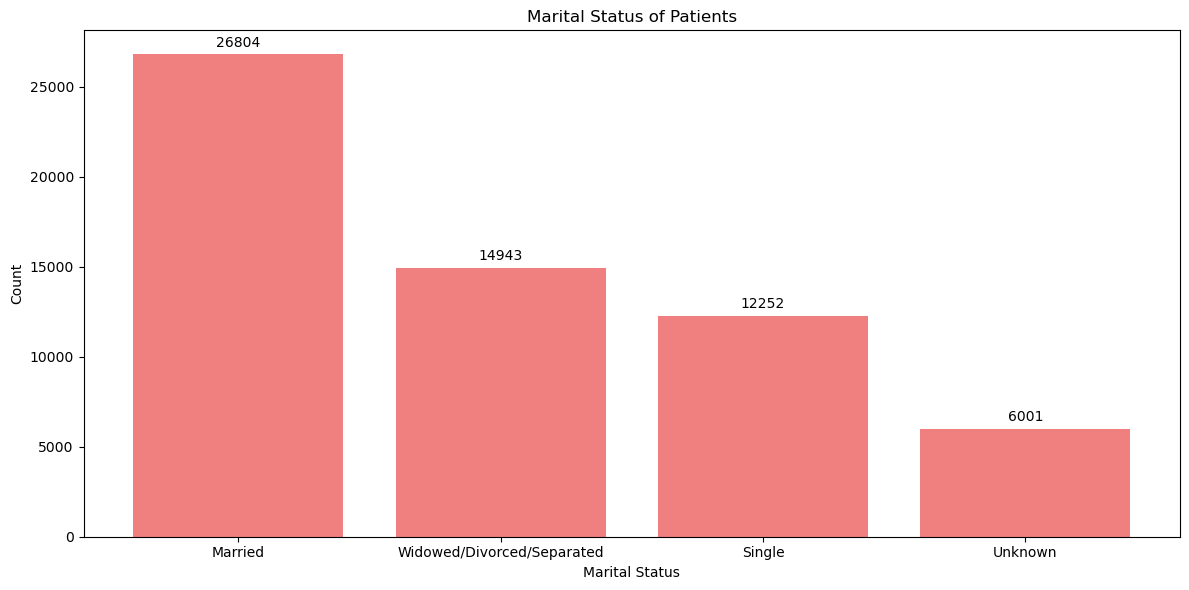

In [183]:
# 5️. Marital Status
import textwrap
def split_label(label, max_length=10):
    if len(label) > max_length:
        words = label.split()
        if len(words) >= 2:
            return '\n'.join([' '.join(words[:len(words)//2]), 
                             ' '.join(words[len(words)//2:])])
    return label

value_counts = patients['marital_status'].value_counts()

wrapped_labels = [split_label(label) for label in value_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(value_counts)), value_counts.values, color='lightcoral')
plt.title("Marital Status of Patients")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.xticks(range(len(value_counts)), wrapped_labels, rotation=0)

for i, v in enumerate(value_counts.values):
    plt.text(i, v + 0.01 * max(value_counts.values), 
             str(v), 
             ha='center', 
             va='bottom')

plt.tight_layout()
plt.show()

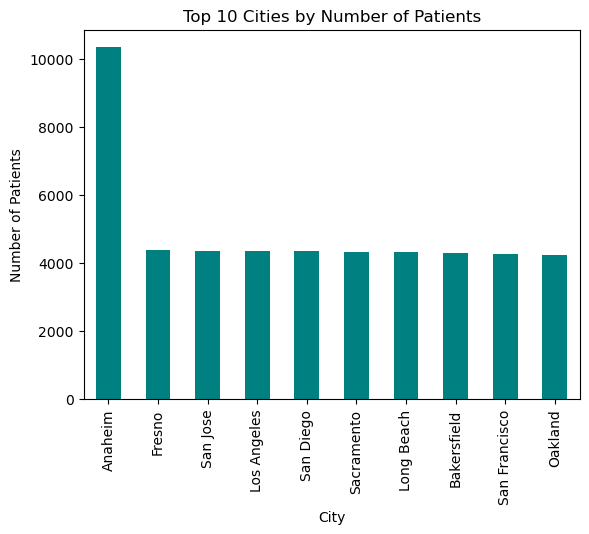

In [184]:
# 6️. Geographic Distribution
city_counts = patients['city'].value_counts().head(10)
city_counts.plot(kind='bar', color='teal')
plt.title("Top 10 Cities by Number of Patients")
plt.xlabel("City")
plt.ylabel("Number of Patients")
plt.show()

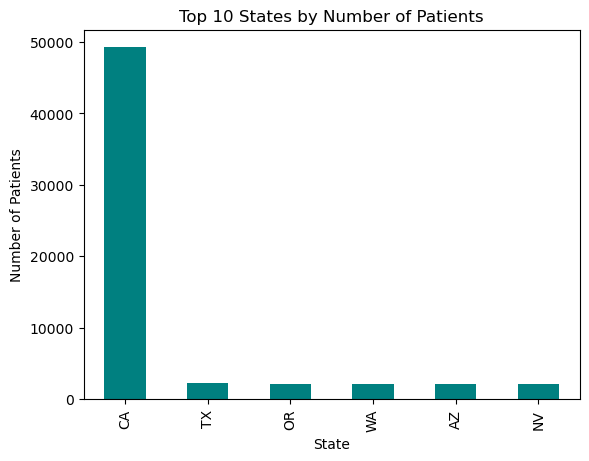

In [185]:
state_counts = patients['state'].value_counts().head(10)
state_counts.plot(kind='bar', color='teal')
plt.title("Top 10 States by Number of Patients")
plt.xlabel("State")
plt.ylabel("Number of Patients")
plt.show()

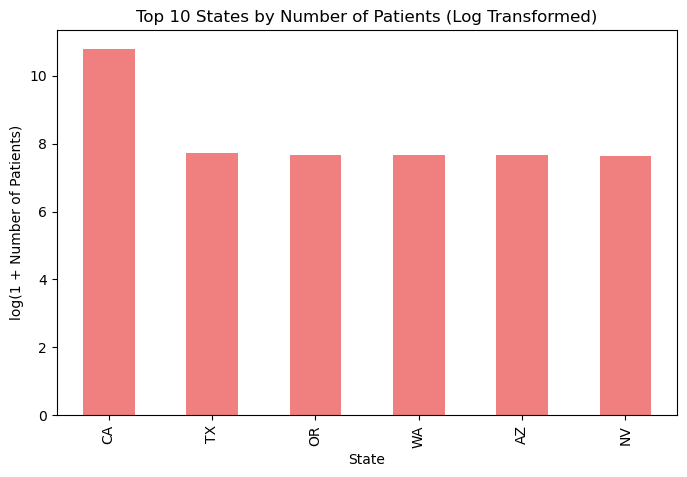

In [186]:
# by using log trick


state_counts = patients['state'].value_counts().head(10)


log_counts = np.log1p(state_counts)

plt.figure(figsize=(8,5))
log_counts.plot(kind='bar', color='lightcoral')
plt.title("Top 10 States by Number of Patients (Log Transformed)")
plt.xlabel("State")
plt.ylabel("log(1 + Number of Patients)")
plt.show()



In [187]:
state_counts = patients['state'].value_counts().reset_index()
state_counts.columns = ['state', 'count']
fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',  
    color='count',
    color_continuous_scale='Tealgrn',
    scope='usa',
    title='Distribution of Patients by State'
)
fig.show()


In [188]:
# provider analysis

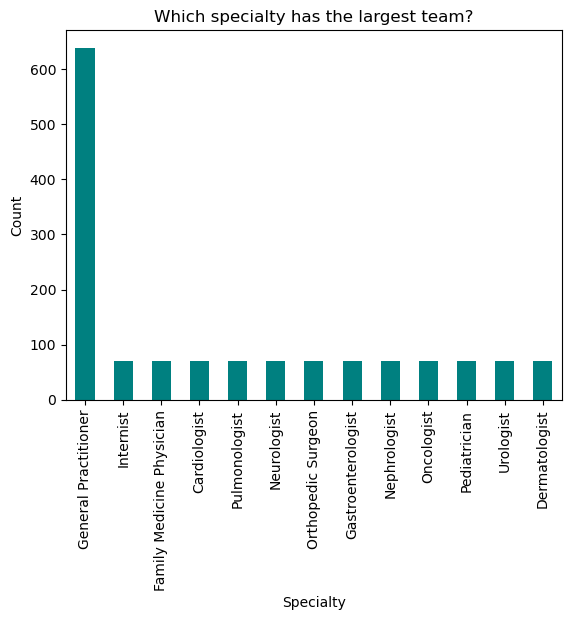

In [189]:
# 1. Number of Providers per Specialty
providers['specialty'].value_counts().plot(kind='bar', color='teal')
plt.title("Which specialty has the largest team?")
plt.xlabel("Specialty")
plt.ylabel("Count")
plt.show()

C:\Users\Radwa\AppData\Local\Temp\ipykernel_23356\1222717291.py:15: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



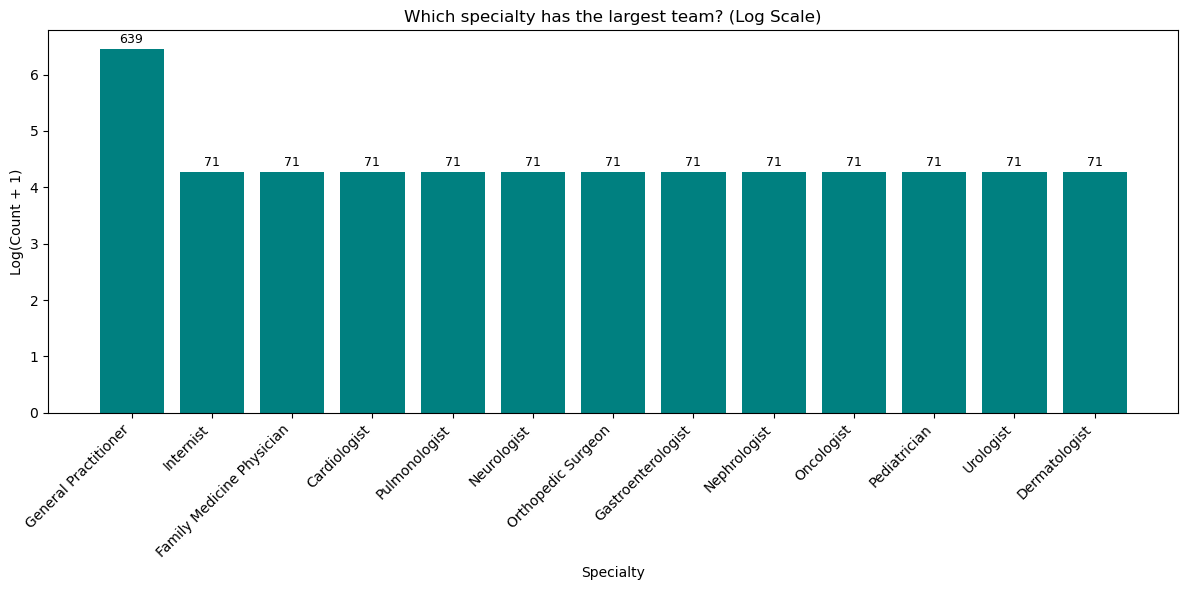

In [190]:
# 1. Number of Providers per Specialty by using log trick
specialty_counts = providers['specialty'].value_counts()


log_values = np.log1p(specialty_counts)  

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(specialty_counts)), log_values, color='teal')
plt.title("Which specialty has the largest team? (Log Scale)")
plt.xlabel("Specialty")
plt.ylabel("Log(Count + 1)")
plt.xticks(range(len(specialty_counts)), specialty_counts.index, rotation=45, ha='right')

for i, (idx, original_value) in enumerate(specialty_counts.items()):
    plt.text(i, log_values[i] + 0.05, 
             f'{original_value}', 
             ha='center', 
             va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()

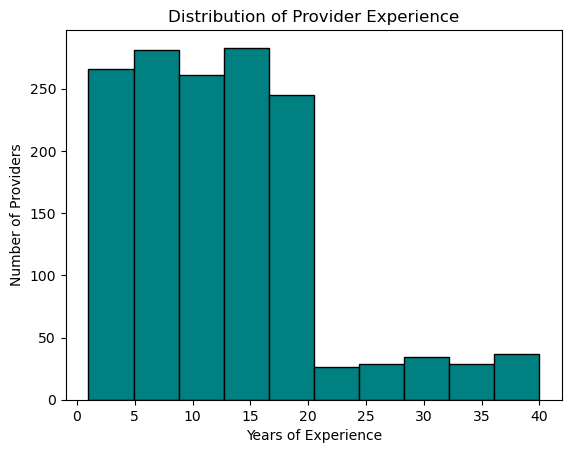

In [191]:
# 3️. Years of Experience Distribution
providers['years_experience'].plot(kind='hist', bins=10, color='teal', edgecolor='black')
plt.title("Distribution of Provider Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Providers")
plt.show()

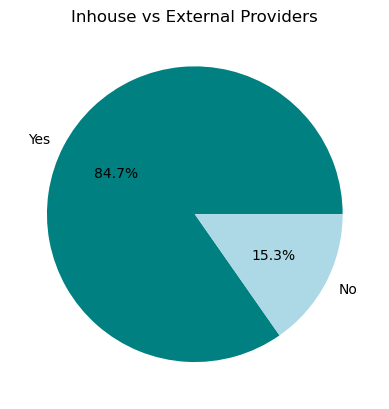

In [192]:
# 4️. Inhouse vs External Providers
providers['inhouse'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['teal','lightblue'])
plt.title("Inhouse vs External Providers")
plt.ylabel("")
plt.show()

In [193]:
# Claims and billing Analysis

In [194]:
# 1️. Total Billed vs Paid Amount
total_billed = billing["billed_amount"].sum()
total_paid = billing["paid_amount"].sum()
recovery_rate = (total_paid / total_billed) * 100
print(f"Total Billed: ${total_billed:,.2f}")
print(f"Total Paid: ${total_paid:,.2f}")
print(f"Recovery Rate: {recovery_rate:.2f}%")

Total Billed: $112,900,639.84
Total Paid: $72,845,650.54
Recovery Rate: 64.52%


Text(0, 0.5, '')

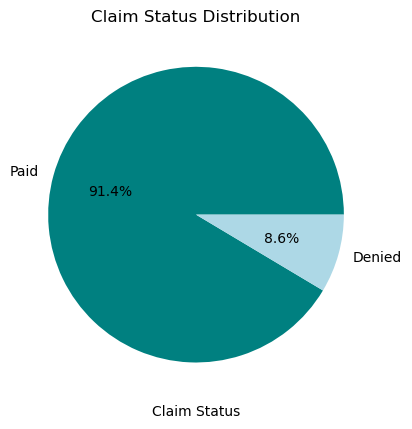

In [195]:
# 2️. Claim Status Distribution
billing["claim_status"].value_counts().plot(kind="pie" , autopct='%1.1f%%', colors=["teal" , "lightblue"])
plt.title("Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("")

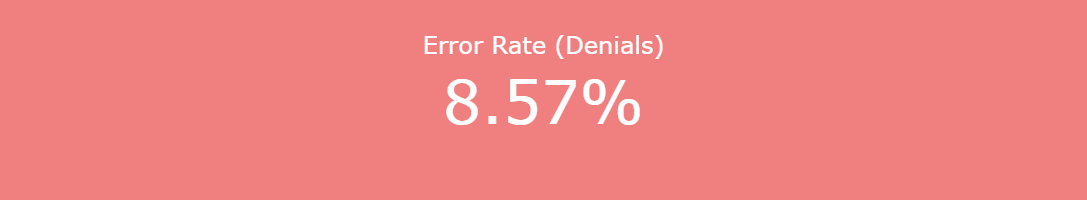

In [200]:
import plotly.graph_objects as go
denial_rate = billing["claim_status"].value_counts(normalize=True).get("Denied", 0) * 100
fig = go.Figure(go.Indicator(
    mode="number",
    value=denial_rate,
    number={'suffix': "%", 'font': {'size': 60, 'color': "white"}},
    title={'text': "Error Rate (Denials)", 'font': {'size': 24, 'color': 'white'}}
))

fig.update_layout(
    width=300,
    height=200,
    margin={'t':50, 'b':50, 'l':20, 'r':20},
    paper_bgcolor="lightcoral"
)

fig.show()


Text(0, 0.5, '')

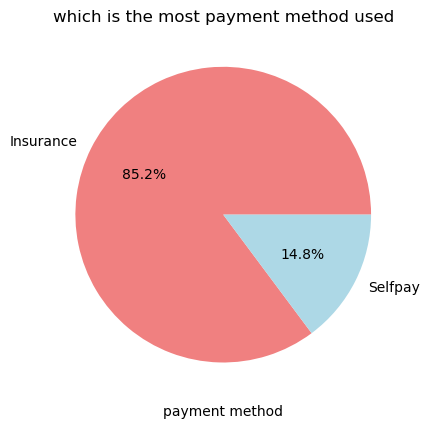

In [197]:
# 2️. Claim Status Distribion
billing["payment_method"].value_counts().plot(kind="pie" , autopct='%1.1f%%', colors=["lightcoral" , "lightblue"])
plt.title("which is the most payment method used")
plt.xlabel("payment method")
plt.ylabel("")

Text(0, 0.5, 'Amount ($)')

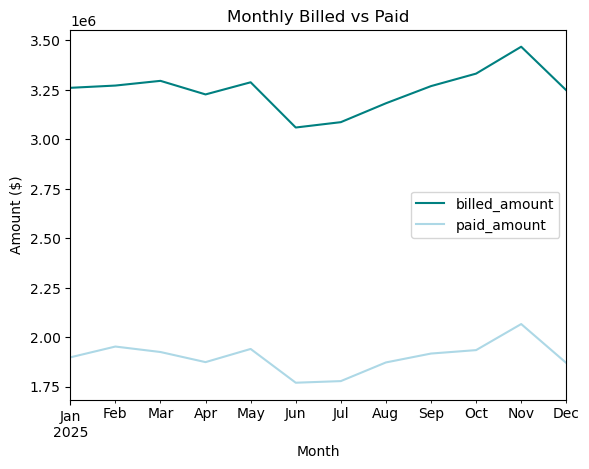

In [198]:
# 3️⃣  Monthly Trend
# plt.subplot(2,2,2)
monthly = billing.groupby(billing["claim_billing_date"].dt.to_period("M"))[["billed_amount","paid_amount"]].sum()
monthly.plot(kind="line", ax=plt.gca(), color=["teal" , "lightblue"])
plt.title("Monthly Billed vs Paid")
plt.xlabel("Month")
plt.ylabel("Amount ($)")

Text(0, 0.5, 'Amount ($)')

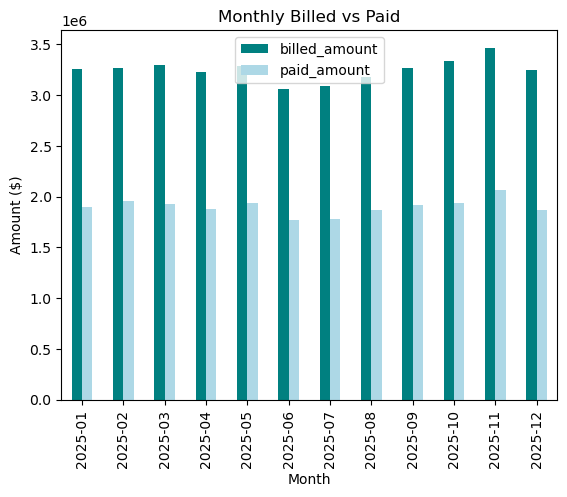

Text(0, 0.5, 'Amount ($)')

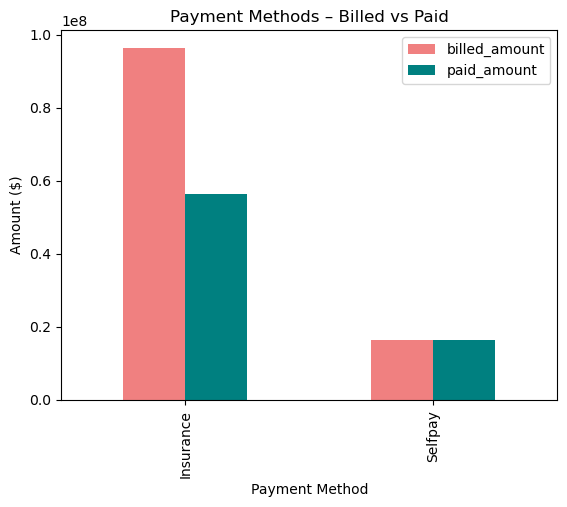

In [203]:
# 4️. Payment Method
billing.groupby("payment_method")[["billed_amount","paid_amount"]].sum().plot(kind="bar", ax=plt.gca(), color=["lightcoral","teal"])
plt.title("Payment Methods – Billed vs Paid")
plt.xlabel("Payment Method")
plt.ylabel("Amount ($)")

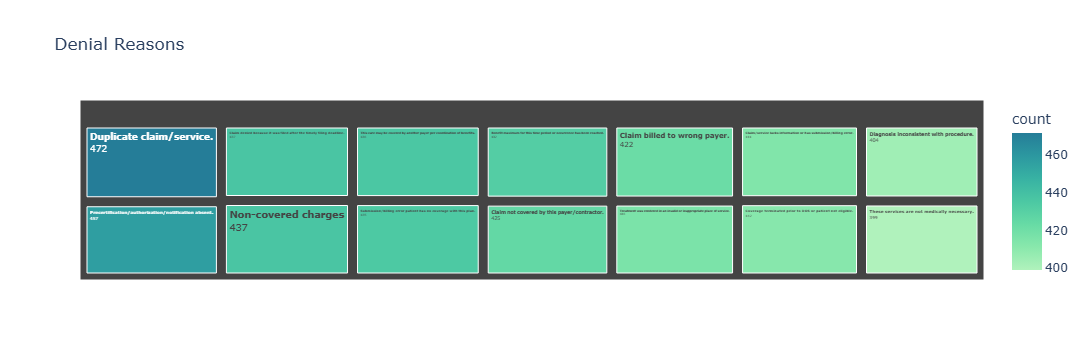

In [219]:
# 1️. Denial Reasons
import plotly.express as px
top_denials = denials["denial_reason_description"].value_counts().reset_index()
top_denials.columns = ['denial_reason', 'count']
fig = px.treemap(
    top_denials,
    path=['denial_reason'],
    values='count',  
    color='count',
    color_continuous_scale='Tealgrn',
    title='Denial Reasons'
)
fig.update_traces(
    textinfo="label+value",
    textfont_size=14,
    tiling=dict(pad=10) 
)
max_count = top_denials['count'].max()
fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value}")  
fig.show()


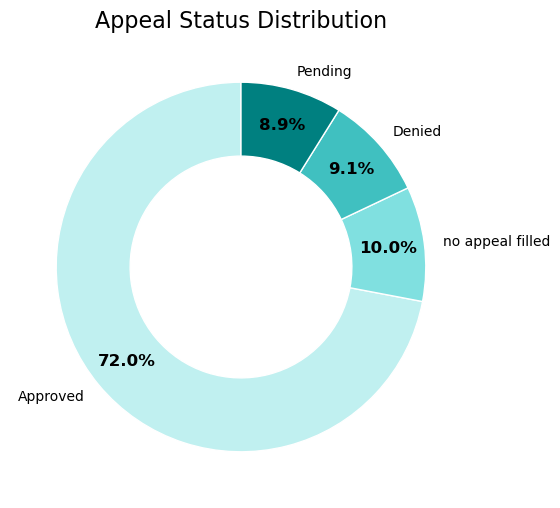

In [229]:
# 2. Appeal Status

appeal_counts = denials["appeal_status"].value_counts()


colors = ['#c0f0f0', '#80e0e0', '#40c0c0', '#008080'] 

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    appeal_counts,
    labels=appeal_counts.index,
    autopct='%1.1f%%',       
    pctdistance=0.8,          
    colors=colors[:len(appeal_counts)],
    startangle=90,
    wedgeprops={'width':0.4, 'edgecolor':'white'}
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title("Appeal Status Distribution", fontsize=16)
plt.show()




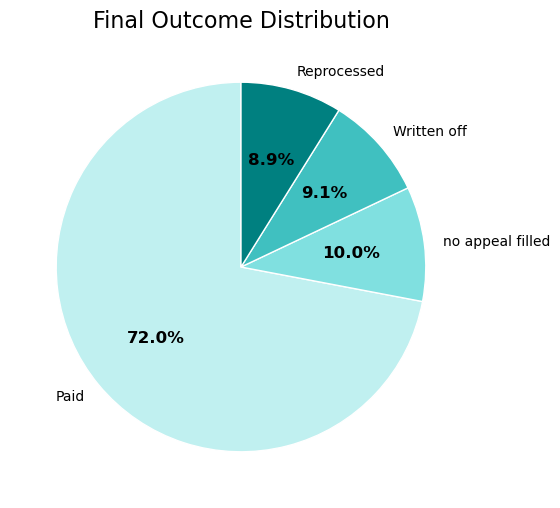

In [234]:
# 3️. Final Outcome
outcome_counts = denials["final_outcome"].value_counts()

colors = ['#c0f0f0', '#80e0e0', '#40c0c0', '#008080']
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct='%1.1f%%',     
    pctdistance=0.6,      
    colors=colors[:len(outcome_counts)],
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':1}
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title("Final Outcome Distribution", fontsize=16)
plt.show()



In [236]:
!pip install streamlit plotly pandas